<a href="https://colab.research.google.com/github/DhruvGangwar320/GitHUB/blob/main/ml_03_3_26(PCA%2CIsolationForest%2CDBCSAN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# PCA Analysis

In [2]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [14]:
import random
study =  [random.randint(0,11) for _ in range(20)] + [20]
study.sort()
marks = [random.randint(50,100) for _ in range(20)] + [20]
marks.sort()
rank = [i for i in range(1,21)] +[21]
data = {
    'StudyHours': study,
    'Marks': marks,
    'Rank' : rank
}

df = pd.DataFrame(data)
print("Original Data:\n", df)

Original Data:
     StudyHours  Marks  Rank
0            0     20     1
1            1     52     2
2            1     52     3
3            2     57     4
4            2     58     5
5            3     59     6
6            4     61     7
7            4     62     8
8            5     62     9
9            5     66    10
10           5     67    11
11           6     70    12
12           6     75    13
13           9     75    14
14          10     84    15
15          10     86    16
16          10     91    17
17          11     92    18
18          11     93    19
19          11     94    20
20          20     96    21


In [15]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

print("\nScaled Data:\n", scaled_data)


Scaled Data:
 [[-1.38186837 -2.73917469 -1.65144565]
 [-1.16849164 -0.98943572 -1.48630108]
 [-1.16849164 -0.98943572 -1.32115652]
 [-0.9551149  -0.71603901 -1.15601195]
 [-0.9551149  -0.66135967 -0.99086739]
 [-0.74173817 -0.60668033 -0.82572282]
 [-0.52836144 -0.49732164 -0.66057826]
 [-0.52836144 -0.4426423  -0.49543369]
 [-0.3149847  -0.4426423  -0.33028913]
 [-0.3149847  -0.22392493 -0.16514456]
 [-0.3149847  -0.16924558  0.        ]
 [-0.10160797 -0.00520756  0.16514456]
 [-0.10160797  0.26818916  0.33028913]
 [ 0.53852223  0.26818916  0.49543369]
 [ 0.75189897  0.76030324  0.66057826]
 [ 0.75189897  0.86966193  0.82572282]
 [ 0.75189897  1.14305864  0.99086739]
 [ 0.9652757   1.19773798  1.15601195]
 [ 0.9652757   1.25241732  1.32115652]
 [ 0.9652757   1.30709667  1.48630108]
 [ 2.8856663   1.41645535  1.65144565]]


In [60]:
pca = PCA(n_components=1)   #Reduce all columns into only 1 new column
pca_data = pca.fit_transform(scaled_data)

print("\nPCA Transformed Data:\n", pca_data)


'''
pca = PCA(n_components=1) #Reduce all columns into only 1 new column when we will make two
components then they will be perpendicular ?
Yes, in PCA, the principal components are always orthogonal (perpendicular) to each other.
This is a fundamental property of PCA, as it seeks to find new axes that are uncorrelated and capture the maximum variance in the data.

Because the new axis has a center (mean = 0)
-1.92 → lowest (small study hours + low marks)
2.05 → highest (high study hours + high marks)
'''


PCA Transformed Data:
 [[-3.3309669 ]
 [-2.10697893]
 [-2.01029239]
 [-1.63448785]
 [-1.5063871 ]
 [-1.25623936]
 [-0.97467742]
 [-0.84657668]
 [-0.62784314]
 [-0.40549979]
 [-0.27739904]
 [ 0.0355771 ]
 [ 0.28933465]
 [ 0.75216218]
 [ 1.25362353]
 [ 1.41313847]
 [ 1.66689602]
 [ 1.91704376]
 [ 2.0451445 ]
 [ 2.17324525]
 [ 3.43118316]]


'Because the new axis has a center (mean = 0)\n-1.92 → lowest (small study hours + low marks)\n2.05 → highest (high study hours + high marks)\n'

In [61]:
print("\nExplained Variance Ratio:", pca.explained_variance_ratio_) #How much important information is kept after applying PCA


Explained Variance Ratio: [0.94839064]


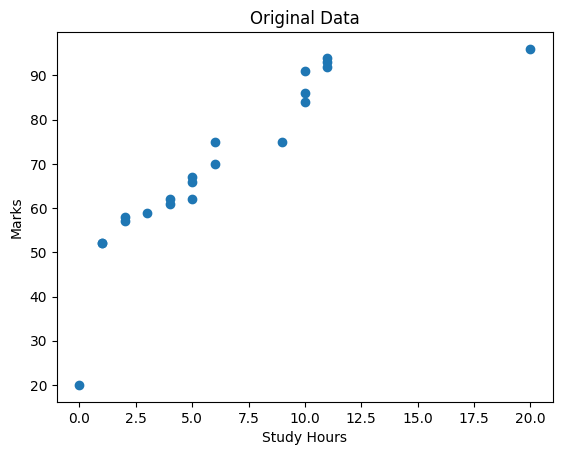

In [65]:
import matplotlib.pyplot as plt

plt.scatter(study, marks)
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Original Data")
plt.show()

#Isolation

In [22]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest

In [23]:
data = {
    'Marks' : marks
}
df = pd.DataFrame(data)
print('Original DataFrame :\n',df)

Original DataFrame :
     Marks
0      20
1      52
2      52
3      57
4      58
5      59
6      61
7      62
8      62
9      66
10     67
11     70
12     75
13     75
14     84
15     86
16     91
17     92
18     93
19     94
20     96


In [45]:
model = IsolationForest(contamination=0.2, random_state=42)
'''
1. contamination=0.2
Meaning: This represents the expected proportion of outliers (anomalies) in your dataset.
Interpretation: A value of 0.2 means you are telling the model that you expect approximately 20% of
 your data to be anomalies.
Usage: It helps the algorithm determine the threshold on the decision function to
classify points as inliers (1) or outliers (-1).
Range: It must be in the range




 or set to 'auto'.
Towards Data Science
Towards Data Science
 +3
2. random_state=42
Meaning: This is the seed used by the random number generator,
ensuring that the results are reproducible.
Purpose: Because IsolationForest builds trees by randomly selecting features and split values,
using random_state=42 ensures that if you run the code multiple times with the same data, you will get the exact same output.
Note: The number 42 is an arbitrary integer;
any integer value will provide the same reproducibility.

'''
df['Anomaly'] = model.fit_predict(df)

print("\nOutput:\n", df)


Output:
     Marks  Anomaly
0      20       -1
1      52        1
2      52        1
3      57        1
4      58        1
5      59        1
6      61        1
7      62        1
8      62        1
9      66        1
10     67        1
11     70        1
12     75        1
13     75        1
14     84       -1
15     86       -1
16     91        1
17     92        1
18     93        1
19     94        1
20     96       -1


In [46]:
# Step 3: Separate Outliers
outliers = df[df['Anomaly'] == -1]
print("\nOutliers:\n", outliers)


Outliers:
     Marks  Anomaly
0      20       -1
14     84       -1
15     86       -1
20     96       -1


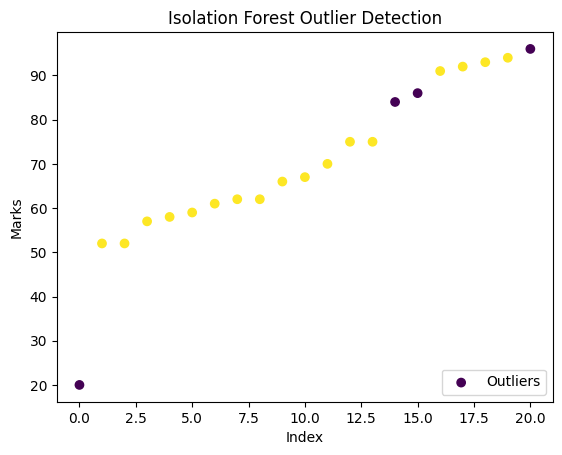

In [56]:
import matplotlib.pyplot as plt

plt.scatter(df.index, df['Marks'], c=df['Anomaly'])
plt.xlabel("Index")
plt.ylabel("Marks")
plt.legend(
    ['Outliers', 'Inliers'],
    loc='lower right'
)
plt.title("Isolation Forest Outlier Detection")
plt.show()

#DBSCAN

In [48]:
import numpy as np
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Step 1: Create a simple dataset
# (2 clusters + some noise points)
X = np.array([
    [1,2],[0,1],[0.5,1],[1,1.5],
    [0,0.5],[1,1],[2,2],[1.5,2],[10,21],[8,8]
])

In [49]:
# Step 2: Apply DBSCAN
model = DBSCAN(eps=3, min_samples=2)
'''
eps (epsilon) defines the maximum distance between two samples for one to be considered as in the neighborhood of the other.
It's essentially the radius around a core point.
If the distance between two points is less than or equal to eps,
they are considered neighbors.
In DBSCAN, min_samples refers to the minimum number of samples (or data points) required in a neighborhood
for a point to be considered as a core point. It includes the point itself.
If a point has at least min_samples within its eps radius, it's marked as a core point.
Otherwise, it's considered a border point or a noise point.
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
eps=0.3: The radius to look for neighboring points.
min_samples: Minimum number of points required to form a dense region a cluster.
labels: Cluster numbers for each point. -1 means the point is considered noise.
'''
labels = model.fit_predict(X)

# Step 3: Print results
print("Data points:\n", X)
print("\nCluster Labels:\n", labels)


'''
0, 1, 2... → cluster IDs
-1 → noise

'''


Data points:
 [[ 1.   2. ]
 [ 0.   1. ]
 [ 0.5  1. ]
 [ 1.   1.5]
 [ 0.   0.5]
 [ 1.   1. ]
 [ 2.   2. ]
 [ 1.5  2. ]
 [10.  21. ]
 [ 8.   8. ]]

Cluster Labels:
 [ 0  0  0  0  0  0  0  0 -1 -1]


'\n0, 1, 2... → cluster IDs\n-1 → noise\n\n'

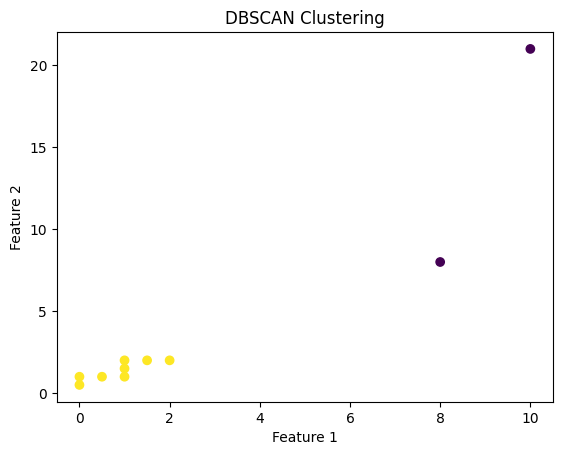

In [50]:
# Step 4: Visualization
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()